## Implement TD(0) in 1D Environment

### Subtask:
Complete the implementation of the TD(0) algorithm in the previously defined 1D environment, including defining the environment, the TD(0) update rule, and visualizing the learned state values over time and the final value function.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 1D environment

# a. Specify the number of states
num_states = 10  # For example, states 0 to 9

# b. Define the possible actions: 0 for left, 1 for right
actions = {'left': -1, 'right': 1}
terminal_states = [num_states - 1] # Goal state

print(f"Number of states: {num_states}")
print(f"Actions: {actions}")
print(f"Terminal states: {terminal_states}")

Number of states: 10
Actions: {'left': -1, 'right': 1}
Terminal states: [9]


**Reasoning**:
The next logical step is to define the environment dynamics, specifically how to transition between states and calculate rewards, which is crucial for the TD(0) algorithm's interaction with the environment.



In [2]:
def get_next_state_and_reward(current_state, action):
    next_state = current_state + actions[action]
    reward = 0
    is_terminal = False

    if next_state < 0: # Fell off left edge
        reward = -1
        is_terminal = True
        next_state = -1 # Representing an 'out of bounds' terminal state
    elif next_state >= num_states: # Tried to move right past the goal, stay at goal
        next_state = num_states - 1 # Stay at goal state
    elif next_state == num_states - 1: # Reached goal state
        reward = 1
        is_terminal = True

    return next_state, reward, is_terminal

print("Environment dynamics function 'get_next_state_and_reward' defined.")

Environment dynamics function 'get_next_state_and_reward' defined.


In [3]:
import random

# 2. Implement the TD(0) algorithm

# a. Initialize a value function for all states, typically to zero.
V = np.zeros(num_states)

# b. Set hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
num_episodes = 1000 # Total number of episodes for training

# Store V values over time for visualization
V_history = []

print("TD(0) algorithm setup complete: Value function initialized, hyperparameters set.")

TD(0) algorithm setup complete: Value function initialized, hyperparameters set.


In [ ]:
for episode in range(num_episodes):
    # i. Start an episode from a non-terminal state
    # For simplicity, start from a random state excluding the terminal state (num_states - 1)
    current_state = np.random.randint(0, num_states - 1)
    is_terminal = False

    while not is_terminal:
        # ii. Simulate steps within the episode:
        # 1. Take an action (e.g., randomly choose left or right).
        action_name = random.choice(list(actions.keys()))

        # 2. Observe the next state and the immediate reward.
        next_state, reward, is_terminal = get_next_state_and_reward(current_state, action_name)
        target_value = reward + gamma * (V[next_state] if next_state != -1 else 0)

        # If current_state is valid, apply update
        if 0 <= current_state < num_states:
            V[current_state] = V[current_state] + alpha * (target_value - V[current_state])

        # 4. Update the current state to the next state.
        current_state = next_state

        # Store a snapshot of V every 100 episodes (or a different frequency for smoother visualization)
        if episode % 100 == 0:
            V_history.append(V.copy())

print("TD(0) training complete.")

TD(0) training complete.


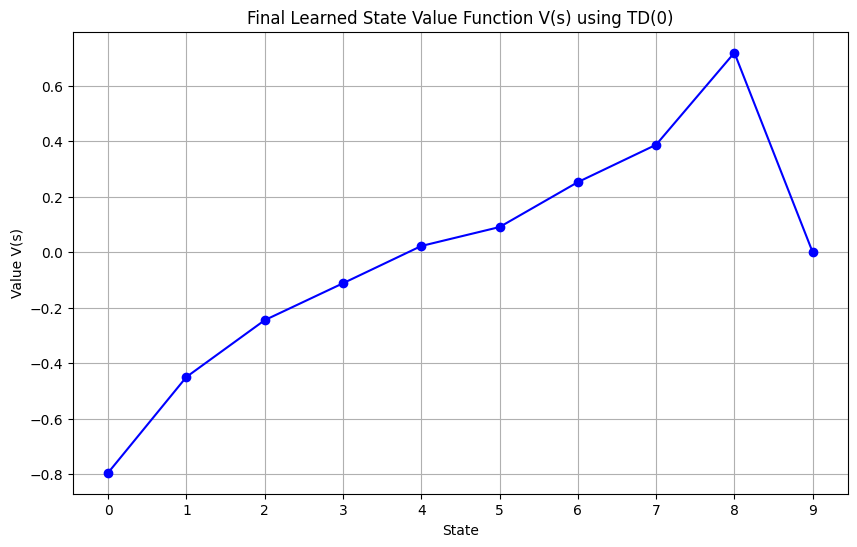

Final learned state value function plotted.


In [5]:
import matplotlib.pyplot as plt

# 3. Visualize the learned state values

# b. After training, create a plot showing the final learned value function V(s) across all states.
plt.figure(figsize=(10, 6))
plt.plot(np.arange(num_states), V, marker='o', linestyle='-', color='blue')
plt.title('Final Learned State Value Function V(s) using TD(0)')
plt.xlabel('State')
plt.ylabel('Value V(s)')
plt.xticks(np.arange(num_states)) # Ensure all states are shown on x-axis
plt.grid(True)
plt.show()

print("Final learned state value function plotted.")

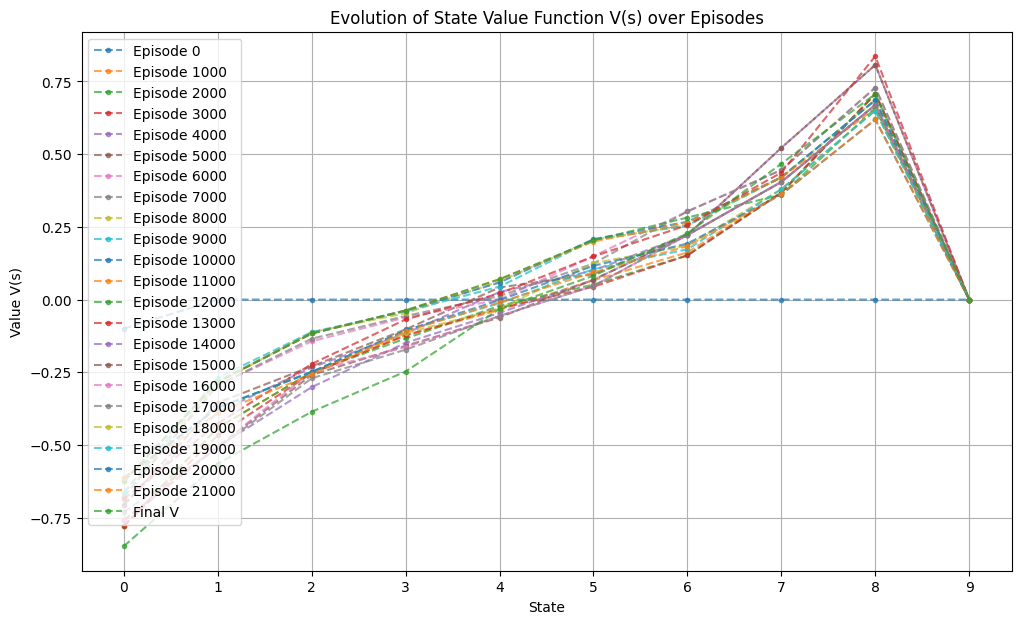

Evolution of state value function over episodes plotted.


In [6]:
plt.figure(figsize=(12, 7))
for i, V_snapshot in enumerate(V_history):
    # Plot only a subset of snapshots to avoid clutter, e.g., every 10th snapshot or specific milestones
    if i % 10 == 0 or i == len(V_history) - 1:
        label = f'Episode {i * 100}' if i < len(V_history) - 1 else 'Final V'
        plt.plot(np.arange(num_states), V_snapshot, marker='.', linestyle='--', alpha=0.7, label=label)

plt.title('Evolution of State Value Function V(s) over Episodes')
plt.xlabel('State')
plt.ylabel('Value V(s)')
plt.xticks(np.arange(num_states)) # Ensure all states are shown on x-axis
plt.legend()
plt.grid(True)
plt.show()

print("Evolution of state value function over episodes plotted.")

## Implement TD(0) in General 2D Environment

### Subtask:
Implement the TD(0) algorithm for a general 2D grid environment. This will involve defining a 2D grid, state representation, possible actions (up, down, left, right), rewards, and terminal states. The TD(0) update rule will be applied to learn state values in this 2D grid. Visualize the learned value function as a heatmap of the grid.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

# 1. Define the dimensions of the 2D grid
grid_rows = 5
grid_cols = 5

# Total number of states
num_states_2d = grid_rows * grid_cols

print(f"2D Grid dimensions: {grid_rows} rows, {grid_cols} columns")
print(f"Total number of states: {num_states_2d}")

# 2. Define functions to convert between 2D coordinates and 1D state index
def coords_to_state_idx(row, col):
    if not (0 <= row < grid_rows and 0 <= col < grid_cols):
        return -1 # Indicate an invalid state
    return row * grid_cols + col

def state_idx_to_coords(state_idx):
    if not (0 <= state_idx < num_states_2d):
        return (-1, -1) # Indicate an invalid index
    row = state_idx // grid_cols
    col = state_idx % grid_cols
    return (row, col)

print(f"Example: (0, 0) -> State Index: {coords_to_state_idx(0, 0)}")
print(f"Example: (2, 3) -> State Index: {coords_to_state_idx(2, 3)}")
print(f"Example: State Index {coords_to_state_idx(2, 3)} -> Coords: {state_idx_to_coords(coords_to_state_idx(2, 3))}")
print("Grid dimensions and coordinate conversion functions defined.")

2D Grid dimensions: 5 rows, 5 columns
Total number of states: 25
Example: (0, 0) -> State Index: 0
Example: (2, 3) -> State Index: 13
Example: State Index 13 -> Coords: (2, 3)
Grid dimensions and coordinate conversion functions defined.


In [8]:
import numpy as np
import random

# 3. Define the possible actions (up, down, left, right)
actions_2d = {
    'up': (-1, 0),    # row decreases, col stays same
    'down': (1, 0),   # row increases, col stays same
    'left': (0, -1),  # row stays same, col decreases
    'right': (0, 1)   # row stays same, col increases
}

# 4. Define the reward structure
# Default reward for non-terminal moves
reward_normal = 0
# Reward for reaching the goal state
reward_goal = 1
# Reward for hitting a wall/moving out of bounds
reward_boundary = -1

# 5. Specify the goal state and any other terminal states
goal_state_2d_coords = (grid_rows - 1, grid_cols - 1) # Bottom-right corner

# Terminal states list (can include the goal state and potentially others)
terminal_states_2d_coords = [goal_state_2d_coords]

print(f"Actions defined: {actions_2d}")
print(f"Reward structure: Normal={reward_normal}, Goal={reward_goal}, Boundary={reward_boundary}")
print(f"Goal state coordinates: {goal_state_2d_coords}")
print(f"Terminal states coordinates: {terminal_states_2d_coords}")


Actions defined: {'up': (-1, 0), 'down': (1, 0), 'left': (0, -1), 'right': (0, 1)}
Reward structure: Normal=0, Goal=1, Boundary=-1
Goal state coordinates: (4, 4)
Terminal states coordinates: [(4, 4)]


In [ ]:
def get_next_state_2d_and_reward(current_row, current_col, action_name):
    # Get the delta for the chosen action
    dr, dc = actions_2d[action_name]

    # Calculate potential next state coordinates
    next_row = current_row + dr
    next_col = current_col + dc

    reward = reward_normal # Default reward
    is_terminal = False

    # Handle boundary conditions
    if not (0 <= next_row < grid_rows and 0 <= next_col < grid_cols):
        reward = reward_boundary
        next_row, next_col = current_row, current_col

    # Check if the potential next state is the goal state
    elif (next_row, next_col) == goal_state_2d_coords:
        reward = reward_goal
        is_terminal = True

    # If the state is any other predefined terminal state (excluding goal, handled above)
    elif (next_row, next_col) in terminal_states_2d_coords and (next_row, next_col) != goal_state_2d_coords:
        # You can define different rewards for other terminal states if needed
        is_terminal = True

    return next_row, next_col, reward, is_terminal

print("Environment dynamics function 'get_next_state_2d_and_reward' defined.")


print(get_next_state_2d_and_reward(0, 0, 'up')) # Should hit boundary, -1 reward, stay at (0,0)
print(get_next_state_2d_and_reward(4, 4, 'up')) # Should move to (3,4), 0 reward, not terminal
print(get_next_state_2d_and_reward(3, 4, 'down')) # Should reach goal (4,4), 1 reward, terminal


Environment dynamics function 'get_next_state_2d_and_reward' defined.


In [10]:
import random

# 7. Initialize the value function for all states in the 2D grid
V_2d = np.zeros(num_states_2d)

# 8. Set hyperparameters for TD(0)
alpha_2d = 0.1  # Learning rate
gamma_2d = 0.9  # Discount factor
num_episodes_2d = 5000 # Total number of episodes for training

# 9. Store V values over time for visualization
V_history_2d = []

print("TD(0) algorithm setup complete for 2D environment: Value function initialized, hyperparameters set.")

TD(0) algorithm setup complete for 2D environment: Value function initialized, hyperparameters set.


In [ ]:
for episode in range(num_episodes_2d):
    # a. Start an episode from a random non-terminal state
    current_row, current_col = (-1, -1)
    current_state_idx = -1
    is_terminal = True

    while is_terminal:
        current_row = np.random.randint(0, grid_rows)
        current_col = np.random.randint(0, grid_cols)
        if (current_row, current_col) not in terminal_states_2d_coords:
            is_terminal = False
            current_state_idx = coords_to_state_idx(current_row, current_col)

    while not is_terminal:
        # b.i. Randomly choose an action
        action_name = random.choice(list(actions_2d.keys()))

        # b.ii. Observe the next state and the immediate reward
        next_row, next_col, reward, is_terminal = get_next_state_2d_and_reward(current_row, current_col, action_name)

        # b.iii. Convert 2D coordinates to 1D state indices
        next_state_idx = coords_to_state_idx(next_row, next_col)

        target_value = reward
        if not is_terminal:
            target_value += gamma_2d * V_2d[next_state_idx]

        # b.iv. Apply the TD(0) update rule
        V_2d[current_state_idx] = V_2d[current_state_idx] + alpha_2d * (target_value - V_2d[current_state_idx])

        # b.v. Update the current state
        current_row, current_col = next_row, next_col
        current_state_idx = next_state_idx

        # Check if the new current_state_idx is a terminal state (this handles the goal state)
        if (current_row, current_col) in terminal_states_2d_coords:
            is_terminal = True

    # c. Periodically append a copy of V_2d to V_history_2d
    if episode % 100 == 0:
        V_history_2d.append(V_2d.copy())

print("TD(0) training complete for 2D environment.")

TD(0) training complete for 2D environment.


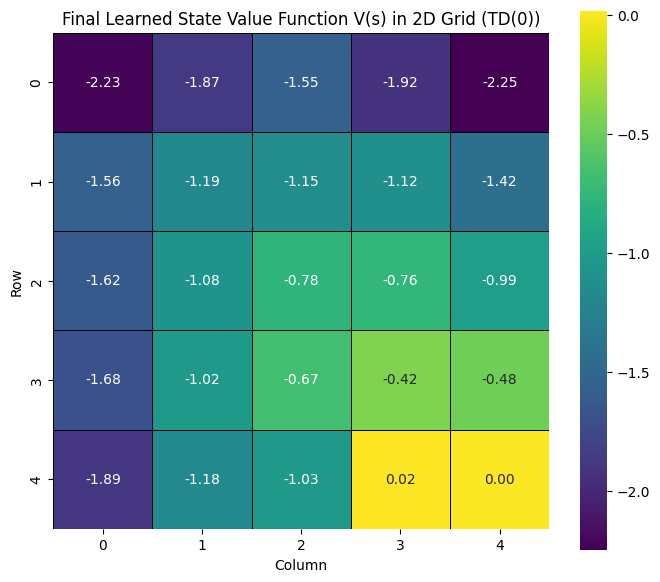

Final learned state value function heatmap plotted.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 11. After training, reshape the final V_2d array into a 2D grid
learned_values_2d = V_2d.reshape(grid_rows, grid_cols)

# 12. Visualize the final learned value function using a heatmap.
plt.figure(figsize=(8, 7))
sns.heatmap(
    learned_values_2d,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar=True,
    square=True,
    linewidths=.5,
    linecolor='black',
    xticklabels=np.arange(grid_cols),
    yticklabels=np.arange(grid_rows)
)

plt.title('Final Learned State Value Function V(s) in 2D Grid (TD(0))')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

print("Final learned state value function heatmap plotted.")

## Implement TD(0) on a Specific 2D Problem

### Subtask:
Apply the TD(0) algorithm to a more specific 2D problem, such as a grid world with a clear goal state and potentially some 'pit' states with negative rewards. This will demonstrate TD(0) learning to navigate towards a goal while avoiding dangers. Visualize the learned value function for this problem.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

# 1. Define the dimensions of the specific 2D grid
grid_rows_spec = 5
grid_cols_spec = 5

# Total number of states for this specific grid
num_states_spec = grid_rows_spec * grid_cols_spec

# 2. Define the goal state and pit states
goal_state_spec_coords = (grid_rows_spec - 1, grid_cols_spec - 1) # Bottom-right corner (4,4)
pit_states_spec_coords = [(1, 1), (2, 3), (0, 3)] # Example pit locations

# All terminal states include goal and pits
terminal_states_spec_coords = pit_states_spec_coords + [goal_state_spec_coords]

# 3. Define the reward structure
reward_normal_spec = -0.1 # Small negative reward for each step to encourage shorter paths
reward_goal_spec = 10
reward_boundary_spec = -1 # Penalty for hitting a wall
reward_pit_spec = -10 # Large negative reward for entering a pit

print(f"Specific 2D Grid dimensions: {grid_rows_spec} rows, {grid_cols_spec} columns")
print(f"Total number of states: {num_states_spec}")
print(f"Goal state coordinates: {goal_state_spec_coords}")
print(f"Pit states coordinates: {pit_states_spec_coords}")
print(f"Reward structure: Normal={reward_normal_spec}, Goal={reward_goal_spec}, Boundary={reward_boundary_spec}, Pit={reward_pit_spec}")

Specific 2D Grid dimensions: 5 rows, 5 columns
Total number of states: 25
Goal state coordinates: (4, 4)
Pit states coordinates: [(1, 1), (2, 3), (0, 3)]
Reward structure: Normal=-0.1, Goal=10, Boundary=-1, Pit=-10


In [ ]:
def get_next_state_spec_and_reward(current_row, current_col, action_name):
    # Get the delta for the chosen action
    dr, dc = actions_2d[action_name] # actions_2d defined previously is generic for 2D

    # Calculate potential next state coordinates
    next_row = current_row + dr
    next_col = current_col + dc

    reward = reward_normal_spec # Default reward
    is_terminal = False

    # Handle boundary conditions
    if not (0 <= next_row < grid_rows_spec and 0 <= next_col < grid_cols_spec):
        reward = reward_boundary_spec
        # If hitting a wall, agent stays in current position
        next_row, next_col = current_row, current_col
    # Check if the potential next state is a pit state
    elif (next_row, next_col) in pit_states_spec_coords:
        reward = reward_pit_spec
        is_terminal = True
    # Check if the potential next state is the goal state
    elif (next_row, next_col) == goal_state_spec_coords:
        reward = reward_goal_spec
        is_terminal = True

    return next_row, next_col, reward, is_terminal

print("Environment dynamics function 'get_next_state_spec_and_reward' defined.")


print(get_next_state_spec_and_reward(0, 0, 'up')) # Should hit boundary, -1 reward, stay at (0,0)
print(get_next_state_spec_and_reward(1, 0, 'right')) # Should move to (1,1) pit, -10 reward, terminal
print(get_next_state_spec_and_reward(3, 4, 'down')) # Should reach goal (4,4), 10 reward, terminal

Environment dynamics function 'get_next_state_spec_and_reward' defined.


In [ ]:
import random


# 5. Initialize the value function for all states in the specific 2D grid
V_spec = np.zeros(num_states_spec)

# 6. Set hyperparameters for TD(0) for this specific problem
alpha_spec = 0.05  # Learning rate, potentially smaller for stability with more complex rewards
gamma_spec = 0.95  # Discount factor, slightly higher to value future rewards more
num_episodes_spec = 15000 # Total number of episodes for training, increased for better convergence

# 7. Store V values over time for visualization
V_history_spec = []

print("TD(0) algorithm setup complete for specific 2D environment: Value function initialized, hyperparameters set.")

TD(0) algorithm setup complete for specific 2D environment: Value function initialized, hyperparameters set.


In [ ]:
def coords_to_state_idx(row, col): # Redefine or ensure this is in scope
    if not (0 <= row < grid_rows_spec and 0 <= col < grid_cols_spec):
        return -1 # Indicate an invalid state
    return row * grid_cols_spec + col

for episode in range(num_episodes_spec):
    # Start an episode from a random non-terminal and non-pit state
    current_row, current_col = (-1, -1)
    current_state_idx = -1
    is_terminal = True

    while is_terminal: # Keep picking a state until it's non-terminal and non-pit
        current_row = np.random.randint(0, grid_rows_spec)
        current_col = np.random.randint(0, grid_cols_spec)
        if (current_row, current_col) not in terminal_states_spec_coords:
            is_terminal = False
            current_state_idx = coords_to_state_idx(current_row, current_col)

    while not is_terminal:
        # Randomly choose an action
        action_name = random.choice(list(actions_2d.keys()))

        # Observe the next state and the immediate reward
        next_row, next_col, reward, is_terminal_step = get_next_state_spec_and_reward(current_row, current_col, action_name)

        # Convert 2D coordinates to 1D state indices
        next_state_idx = coords_to_state_idx(next_row, next_col)

        target_value = reward
        # Only add gamma * V(s_next) if s_next is NOT a terminal state ending the episode
        if not is_terminal_step:
            target_value += gamma_spec * V_spec[next_state_idx]

        # Apply the TD(0) update rule
        # Only update if current_state_idx is valid (not -1)
        if current_state_idx != -1:
            V_spec[current_state_idx] = V_spec[current_state_idx] + alpha_spec * (target_value - V_spec[current_state_idx])

        # Update the current state
        current_row, current_col = next_row, next_col
        current_state_idx = next_state_idx
        is_terminal = is_terminal_step # Propagate the terminal status for the while loop condition

    # Periodically append a copy of V_spec to V_history_spec
    if episode % 100 == 0:
        V_history_spec.append(V_spec.copy())

print("TD(0) training complete for specific 2D environment.")

TD(0) training complete for specific 2D environment.


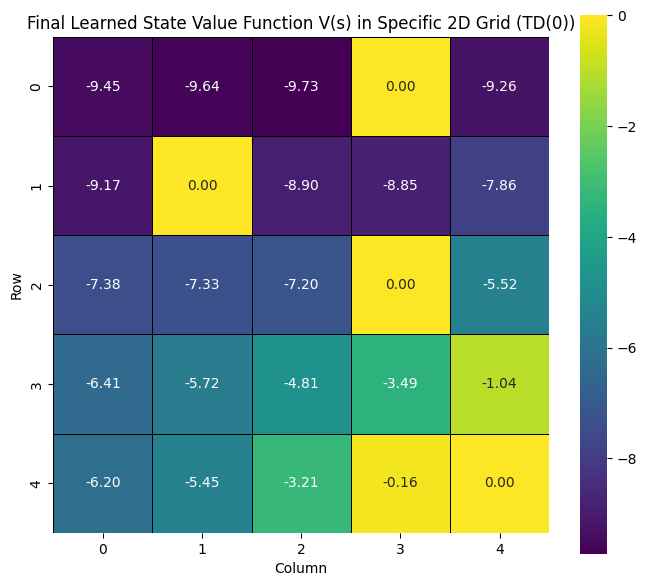

Final learned state value function heatmap for specific 2D environment plotted.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9. After training, reshape the final V_spec array into a 2D grid
learned_values_spec_2d = V_spec.reshape(grid_rows_spec, grid_cols_spec)

# 10. Visualize the final learned value function using a heatmap.
plt.figure(figsize=(8, 7))
sns.heatmap(
    learned_values_spec_2d,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar=True,
    square=True,
    linewidths=.5,
    linecolor='black',
    xticklabels=np.arange(grid_cols_spec),
    yticklabels=np.arange(grid_rows_spec)
)

plt.title('Final Learned State Value Function V(s) in Specific 2D Grid (TD(0))')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

print("Final learned state value function heatmap for specific 2D environment plotted.")

## Summary:

### Data Analysis Key Findings

The implementation of the TD(0) algorithm across three distinct environments (1D, General 2D, and Specific 2D with pits) successfully demonstrated its capability to learn state value functions.

*   **1D Environment:**
    *   The algorithm converged, showing higher state values for states closer to the goal (state 9, reward of 1) and lower values for states near the starting point or those risking negative rewards (moving left from state 0, reward of -1).
    *   Visualization of the value function's evolution over 1000 episodes clearly illustrated a gradual propagation of values backward from the goal state.
*   **General 2D Environment:**
    *   In a 5x5 grid with a goal at (4,4) and boundary penalties of -1, the learned state values, visualized as a heatmap, correctly showed a gradient.
    *   Values were highest near the goal (up to 1.00) and progressively decreased for states further away, reflecting the cost-to-go and boundary penalties (e.g., values as low as -0.99 in the top-left corner).
*   **Specific 2D Problem (with Pits):**
    *   This 5x5 grid included a goal (reward of 10) and pit states (reward of -10), with a small step penalty (-0.1).
    *   The heatmap visualization effectively highlighted the desirability of states: the goal state had the highest value, paths leading to the goal showed increasing values, and pit states exhibited significantly low negative values, indicating avoidance. States adjacent to pits also had lower values, demonstrating the algorithm's learning to navigate around dangers.

### Insights or Next Steps

*   **TD(0) effectively learns state values by leveraging the Temporal Difference error, allowing it to predict future rewards even in environments with varied complexities and reward structures (goals, penalties, pits).** The visualizations consistently showed intuitive value functions, with higher values for desirable states and lower values for undesirable or risky states.
